# Dataset — Cross-Market Portfolio Allocation
**CS437/CS5317 Deep Learning, Spring 2026 | Group 30**
Muhammad Umar Malik (27100139) · Muhammad Moosa Kashif (27100451)

---

This notebook documents the dataset we built for our federated portfolio allocation project. Each of four international equity markets is treated as a separate federated client that holds its own set of stocks and never shares raw price data with the others.

**How the project framing maps to the dataset:**

| Standard prompt | Our equivalent |
|---|---|
| Number of classes | Four federated clients (markets), 30 stocks each |
| Train / val / test splits | Chronological: 2010–2019 / 2020–2021 / 2022–May 2026 |
| Sample images | Return distributions, volatility curves, correlation heatmaps |
| Annotations | Six engineered features from daily log returns |

| Client | Index | Market | Currency |
|---|---|---|---|
| 1 | S&P 500 | United States | USD |
| 2 | FTSE 100 | United Kingdom | GBP |
| 3 | Nikkei 225 | Japan | JPY |
| 4 | KSE-100 | Pakistan | PKR |

**Why we moved from 15 to 30 stocks per client.** Early experiments used 15 stocks. Personalisation methods failed consistently, and one plausible reason was that 15 stocks per client provided too little cross-sectional signal for local models to learn anything meaningfully different from the global model. We expanded to 30 stocks before the main improvement experiments to rule this out as a confound.

**Stock selection.** Applied uniformly across all four markets: long continuous price history with minimal gaps, large-cap/liquid status, and no duplicate economic exposures (e.g. only GOOGL, not both GOOGL and GOOG). S&P 500, FTSE 100, and Nikkei 225 prices come from Yahoo Finance. KSE-100 prices are manually sourced because Yahoo Finance coverage of Pakistani equities is unreliable.

**Survivorship bias.** Selecting current or recent blue-chip constituents excludes companies delisted between 2010 and 2026. This is unavoidable — the portfolio model requires a fixed output dimension. We bound the impact with a sensitivity check in Section 9.

**Balance.** All four clients have exactly 30 stocks, so FL performance differences cannot be attributed to dataset size imbalance.

---
## Section 0 — Setup

In [15]:
%pip install yfinance pandas numpy matplotlib seaborn scipy


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import jensenshannon
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')
os.makedirs('data/KSE100', exist_ok=True)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

PALETTE = {'SP500': '#1f77b4', 'FTSE100': '#ff7f0e',
           'Nikkei225': '#2ca02c', 'KSE100': '#d62728'}
TRADING_DAYS = 252

START_DATE = '2010-01-01'
END_DATE   = '2026-04-01'

TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2021-12-31'
TEST_START = '2022-01-01'
TEST_END   = END_DATE

print(f'Study period : {START_DATE} → {END_DATE}')
print(f'Train        : {START_DATE} → {TRAIN_END}')
print(f'Validation   : {VAL_START} → {VAL_END}')
print(f'Test         : {TEST_START} → {TEST_END}')

Study period : 2010-01-01 → 2026-04-01
Train        : 2010-01-01 → 2019-12-31
Validation   : 2020-01-01 → 2021-12-31
Test         : 2022-01-01 → 2026-04-01


---
## Section 1 — Stock Universe

In [17]:
UNIVERSE = {
    # S&P 500 — 30 old, liquid, blue-chip constituents
    # Selection rule: large-cap index relevance, long trading history, no duplicate share classes.
    # GOOGL is kept as Alphabet exposure; GOOG is excluded to avoid duplicate economic exposure.
    # BRK-B is used for yfinance compatibility.
    'SP500': {
        'tickers': [
            'NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL',
            'AVGO', 'TSLA', 'BRK-B', 'JPM', 'LLY',
            'XOM', 'AMD', 'WMT', 'JNJ', 'V',
            'INTC', 'COST', 'CAT', 'MA', 'CSCO',
            'NFLX', 'PG', 'ORCL', 'KO', 'BAC',
            'HD', 'CVX', 'IBM', 'GE', 'UNH',
        ],
        'currency': 'USD',
        'market': 'United States',
        'index': 'S&P 500',
        'data_source': 'yfinance',
    },

    # FTSE 100 — 30 old, liquid, blue-chip constituents
    # Selection rule: large/liquid FTSE names with long Yahoo Finance histories.
    'FTSE100': {
        'tickers': [
            'HSBA.L', 'AZN.L', 'SHEL.L', 'RR.L', 'ULVR.L',
            'BP.L', 'BATS.L', 'GSK.L', 'RIO.L', 'BA.L',
            'LSEG.L', 'REL.L', 'DGE.L', 'NG.L', 'LLOY.L',
            'BARC.L', 'VOD.L', 'IMB.L', 'PRU.L', 'AAL.L',
            'STAN.L', 'BT-A.L', 'TSCO.L', 'SSE.L', 'ANTO.L',
            'CPG.L', 'EXPN.L', 'ADM.L', 'SGE.L', 'RKT.L',
        ],
        'currency': 'GBP',
        'market': 'United Kingdom',
        'index': 'FTSE 100',
        'data_source': 'yfinance',
    },

    # Nikkei 225 — 30 old, liquid, blue-chip constituents
    # The Nikkei is price-weighted, but we prioritise long-history blue-chip coverage
    # rather than only current highest price-weighted constituents.
    'Nikkei225': {
        'tickers': [
            '6857.T', '9983.T', '8035.T', '9984.T', '4063.T',
            '6762.T', '6954.T', '9433.T', '7203.T', '6758.T',
            '7974.T', '7267.T', '8306.T', '8058.T', '8031.T',
            '9432.T', '8316.T', '6501.T', '7741.T', '6981.T',
            '4502.T', '4503.T', '4568.T', '6902.T', '8001.T',
            '8002.T', '8766.T', '6503.T', '7011.T', '4507.T',
        ],
        'currency': 'JPY',
        'market': 'Japan',
        'index': 'Nikkei 225',
        'data_source': 'yfinance',
    },

    # KSE-100 — 30 old, liquid, blue-chip Pakistani stocks
    # Prices are downloaded manually and stored as data/KSE100/<TICKER>.csv.
    # ENGRO and SYS from the old 15-stock universe are excluded here:
    # ENGRO due to restructuring/ticker-continuity concerns, SYS due to shorter public history.
    'KSE100': {
        'tickers': [
            'OGDC', 'PPL', 'POL', 'ENGRO', 'PSO',
            'SNGP', 'SSGC', 'HUBC', 'KAPCO', 'FFC',
            'ATRL', 'FATIMA', 'EPCL', 'DGKC', 'MLCF',
            'FCCL', 'MCB', 'HBL', 'UBL', 'BAHL',
            'MEBL', 'NBP', 'ABL', 'LCI', 'LOTCHEM',
            'INDU', 'MTL', 'PTC', 'BAFL', 'PKGS',
        ],
        'currency': 'PKR',
        'market': 'Pakistan',
        'index': 'KSE-100',
        'data_source': 'manual_csv',
        # 'data_source': 'yfinance_ka',
    },
}


# Universe integrity checks
for client, info in UNIVERSE.items():
    tickers = info['tickers']
    assert len(tickers) == 30, f'{client} has {len(tickers)} tickers; expected 30.'
    assert len(tickers) == len(set(tickers)), f'{client} contains duplicate tickers.'

print(f'{"Client":<12} {"Index":<12} {"Market":<18} {"Currency":<10} {"Stocks"}')
print('-' * 58)
total = 0
for c, info in UNIVERSE.items():
    n = len(info['tickers'])
    total += n
    print(f"{c:<12} {info['index']:<12} {info['market']:<18} {info['currency']:<10} {n}")
print('-' * 58)
print(f"{'Total':<52} {total}")

Client       Index        Market             Currency   Stocks
----------------------------------------------------------
SP500        S&P 500      United States      USD        30
FTSE100      FTSE 100     United Kingdom     GBP        30
Nikkei225    Nikkei 225   Japan              JPY        30
KSE100       KSE-100      Pakistan           PKR        30
----------------------------------------------------------
Total                                                120


---
## Section 2 — Data Download

In [18]:
import yfinance as yf

FORCE_REDOWNLOAD_YFINANCE = False
FORCE_RELOAD_KSE_MANUAL = True

KSE_MANUAL_DIR = "data/KSE100"


def download_yfinance(client, info):
    print(f'Downloading {client} ({len(info["tickers"])} tickers)...')

    raw = yf.download(
        info["tickers"],
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False,
        threads=True,
        group_by="column",
    )

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        elif "Adj Close" in raw.columns.get_level_values(0):
            prices = raw["Adj Close"].copy()
        else:
            raise ValueError(f"{client}: could not find Close/Adj Close in yfinance output.")
    else:
        prices = raw[["Close"]].copy()
        prices.columns = info["tickers"]

    prices.index = pd.to_datetime(prices.index)
    prices.index.name = "Date"
    prices = prices.reindex(columns=info["tickers"])

    path = f"data/{client}_prices.csv"
    prices.to_csv(path)
    print(f"  Saved {path} | shape: {prices.shape}")
    return prices


def parse_manual_kse_price_file(path, ticker):
    """
    Load one manually downloaded KSE historical price file.

    Supported columns:
      Date + Price
      Date + Close
      Date + Adj Close
      Date + Adjusted Close
      Date + Last
      Date + Close Price

    The returned series is indexed by Date and named by ticker.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing manual KSE file for {ticker}: {path}")

    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]

    if "Date" not in df.columns:
        raise ValueError(f"{ticker}: no 'Date' column found. Columns: {list(df.columns)}")

    price_col = None
    for candidate in ["Price", "Close", "Adj Close", "Adjusted Close", "Last", "Close Price"]:
        if candidate in df.columns:
            price_col = candidate
            break

    if price_col is None:
        raise ValueError(
            f"{ticker}: no recognised price column found. "
            f"Expected Price/Close/Adj Close/Adjusted Close/Last/Close Price. "
            f"Columns: {list(df.columns)}"
        )

    out = df[["Date", price_col]].copy()
    out.columns = ["Date", ticker]

    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")

    out[ticker] = (
        out[ticker]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("--", "", regex=False)
        .str.strip()
    )
    out[ticker] = pd.to_numeric(out[ticker], errors="coerce")

    out = out.dropna(subset=["Date", ticker])
    out = out.drop_duplicates(subset=["Date"], keep="last")
    out = out.set_index("Date").sort_index()
    out = out.loc[START_DATE:END_DATE]

    return out[ticker]


def find_manual_kse_file(ticker):
    """
    Accepts either:
      data/manual_kse/OGDC.csv
    or any filename beginning with ticker, e.g.:
      data/manual_kse/OGDC Stock Price History.csv
    """
    exact_path = os.path.join(KSE_MANUAL_DIR, f"{ticker}.csv")
    if os.path.exists(exact_path):
        return exact_path

    if not os.path.exists(KSE_MANUAL_DIR):
        raise FileNotFoundError(f"KSE manual folder does not exist: {KSE_MANUAL_DIR}")

    candidates = [
        os.path.join(KSE_MANUAL_DIR, f)
        for f in os.listdir(KSE_MANUAL_DIR)
        if f.lower().endswith(".csv") and f.upper().startswith(ticker.upper())
    ]

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:
        raise ValueError(
            f"Multiple manual files found for {ticker}: {candidates}. "
            f"Rename one to {ticker}.csv."
        )

    raise FileNotFoundError(
        f"No manual file found for {ticker}. Expected {exact_path} "
        f"or a CSV beginning with '{ticker}'."
    )


def load_kse_manual():
    print(f"Loading KSE100 manually from {KSE_MANUAL_DIR}...")

    frames = []
    report_rows = []

    for ticker in UNIVERSE["KSE100"]["tickers"]:
        path = find_manual_kse_file(ticker)
        s = parse_manual_kse_price_file(path, ticker)

        frames.append(s)

        # report_rows.append({
        #     "Ticker": ticker,
        #     "File": path,
        #     "First date": s.index.min().strftime("%Y-%m-%d") if len(s) else None,
        #     "Last date": s.index.max().strftime("%Y-%m-%d") if len(s) else None,
        #     "Rows": len(s),
        #     "Missing inside own series %": 100 * s.isna().mean(),
        # })

        # print(
        #     f"  {ticker:<8} | {s.index.min().date()} → {s.index.max().date()} "
        #     f"| rows={len(s)} | file={os.path.basename(path)}"
        # )

    prices = pd.concat(frames, axis=1).sort_index()
    prices.index.name = "Date"

    # Preserve declared ticker order
    prices = prices.reindex(columns=UNIVERSE["KSE100"]["tickers"])

    # Restrict to study window
    prices = prices.loc[START_DATE:END_DATE]

    path = "data/KSE100_prices.csv"
    prices.to_csv(path)
    print(f"  Saved {path} | shape: {prices.shape}")

    return prices


prices = {}

for client, info in UNIVERSE.items():
    path = f"data/{client}_prices.csv"

    cache_is_valid = False
    if os.path.exists(path):
        cached = pd.read_csv(path, index_col="Date", parse_dates=True)
        cache_is_valid = (
            cached.shape[1] == len(info["tickers"]) and
            list(cached.columns) == info["tickers"]
        )

    force_rebuild_this_client = (
        FORCE_REDOWNLOAD_YFINANCE or
        (client == "KSE100" and FORCE_RELOAD_KSE_MANUAL)
    )

    if cache_is_valid and not force_rebuild_this_client:
        prices[client] = cached
        print(f"{client}: loaded valid cache | shape: {prices[client].shape}")

    else:
        if os.path.exists(path):
            print(f"{client}: cache missing, stale, or rebuild requested; rebuilding.")

        if info["data_source"] == "yfinance":
            prices[client] = download_yfinance(client, info)

        elif info["data_source"] in ["manual_csv", "manual_kse"]:
            prices[client] = load_kse_manual()

        else:
            raise ValueError(f'Unknown data source for {client}: {info["data_source"]}')


# Final checks
for client, info in UNIVERSE.items():
    assert client in prices, f"{client} missing from prices."
    assert prices[client].shape[1] == 30, (
        f"{client} has {prices[client].shape[1]} columns, expected 30."
    )
    assert list(prices[client].columns) == info["tickers"], (
        f"{client} column order mismatch."
    )

print("\nAll four markets loaded with 30 stocks each.")

SP500: loaded valid cache | shape: (4085, 30)
FTSE100: loaded valid cache | shape: (4104, 30)
Nikkei225: loaded valid cache | shape: (3992, 30)
KSE100: cache missing, stale, or rebuild requested; rebuilding.
Loading KSE100 manually from data/KSE100...
  Saved data/KSE100_prices.csv | shape: (4028, 30)

All four markets loaded with 30 stocks each.


---
## Section 3 — Dataset Overview

In [19]:
rows = []
for client, df in prices.items():
    info = UNIVERSE[client]
    rows.append({
        'Client':         client,
        'Index':          info['index'],
        'Market':         info['market'],
        'Currency':       info['currency'],
        'Stocks loaded':  df.shape[1],
        'Trading days':   df.shape[0],
        'First date':     df.index.min().strftime('%Y-%m-%d'),
        'Last date':      df.index.max().strftime('%Y-%m-%d'),
        'Missing %':      f"{df.isnull().mean().mean()*100:.2f}%",
    })

pd.DataFrame(rows).set_index('Client')

,Index,Market,Currency,Stocks loaded,Trading days,First date,Last date,Missing %
Client,,,,,,,,
SP500,S&P 500,United States,USD,30,4085,2010-01-04,2026-03-31,0.10%
FTSE100,FTSE 100,United Kingdom,GBP,30,4104,2010-01-04,2026-03-31,0.00%
Nikkei225,Nikkei 225,Japan,JPY,30,3992,2010-01-04,2026-03-31,0.00%
KSE100,KSE-100,Pakistan,PKR,30,4028,2010-01-04,2026-03-31,0.23%


In [20]:
# Per-ticker missing data — flag anything above 5%
for client, df in prices.items():
    flagged = (df.isnull().mean() * 100)[lambda x: x > 5]
    if len(flagged):
        print(f'[{client}] Tickers with >5% missing:')
        for t, pct in flagged.items():
            print(f'  {t}: {pct:.1f}%')
    else:
        print(f'[{client}] All tickers below 5% missing threshold ✓')

[SP500] All tickers below 5% missing threshold ✓
[FTSE100] All tickers below 5% missing threshold ✓
[Nikkei225] All tickers below 5% missing threshold ✓
[KSE100] All tickers below 5% missing threshold ✓


---
## Section 4 — Train / Validation / Test Split

All splits are strictly chronological. Training statistics used for normalisation are computed on the training set only and reused on validation and test — no future information leaks in.

| Split | Period | Market conditions |
|---|---|---|
| Train | 2010–2019 | Bull market, taper tantrum, Brexit vote, 2018 volatility spike |
| Validation | 2020–2021 | COVID crash and recovery |
| Test | 2022–April 2026 | Inflation shock, aggressive rate hikes, AI-driven equity rally |

In [21]:
def make_splits(df):
    return {
        'train': df.loc[:TRAIN_END],
        'val':   df.loc[VAL_START:VAL_END],
        'test':  df.loc[TEST_START:TEST_END],
    }

splits = {c: make_splits(df) for c, df in prices.items()}

rows = []
for c, s in splits.items():
    rows.append({
        'Client':     c,
        'Train days': len(s['train']),
        'Val days':   len(s['val']),
        'Test days':  len(s['test']),
        'Train end':  s['train'].index.max().strftime('%Y-%m-%d'),
        'Val end':    s['val'].index.max().strftime('%Y-%m-%d'),
        'Test end':   s['test'].index.max().strftime('%Y-%m-%d'),
    })
pd.DataFrame(rows).set_index('Client')

,Train days,Val days,Test days,Train end,Val end,Test end
Client,,,,,,
SP500,2516,505,1064,2019-12-31,2021-12-31,2026-03-31
FTSE100,2526,507,1071,2019-12-31,2021-12-31,2026-03-31
Nikkei225,2469,487,1036,2019-12-30,2021-12-30,2026-03-31
KSE100,2479,498,1051,2019-12-31,2021-12-31,2026-03-31


[SP500] train/val overlap: False  |  val/test overlap: False  →  PASS
[FTSE100] train/val overlap: False  |  val/test overlap: False  →  PASS
[Nikkei225] train/val overlap: False  |  val/test overlap: False  →  PASS
[KSE100] train/val overlap: False  |  val/test overlap: False  →  PASS

All splits clean ✓


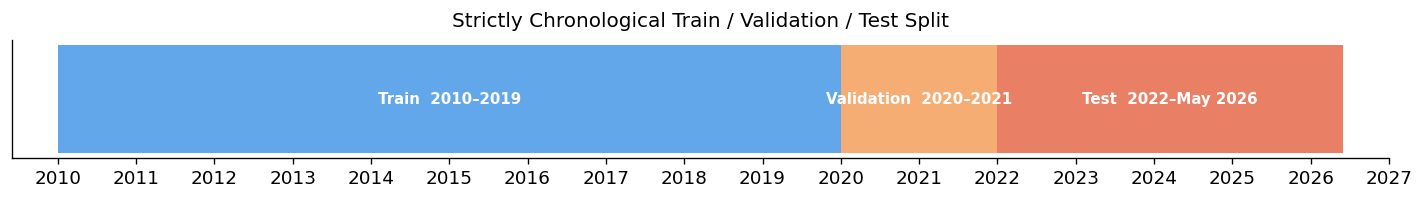

In [22]:
# Leakage check
all_clean = True
for c, s in splits.items():
    tv = s['train'].index.max() >= s['val'].index.min()
    vt = s['val'].index.max()   >= s['test'].index.min()
    ok = not tv and not vt
    if not ok: all_clean = False
    print(f'[{c}] train/val overlap: {tv}  |  val/test overlap: {vt}  →  {"PASS" if ok else "FAIL"}')
print('\nAll splits clean ✓' if all_clean else '\nWARNING: overlap detected')

# Timeline diagram
fig, ax = plt.subplots(figsize=(12, 1.8))
for label, start, end, color in [
    ('Train  2010–2019',      '2010-01-01', '2019-12-31', '#4c9be8'),
    ('Validation  2020–2021', '2020-01-01', '2021-12-31', '#f4a261'),
    ('Test  2022–May 2026',   '2022-01-01', '2026-05-31', '#e76f51'),
]:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    ax.barh(0, (e - s).days, left=s, height=0.5, color=color, alpha=0.88)
    ax.text(s + (e - s)/2, 0, label, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(pd.Timestamp('2009-06-01'), pd.Timestamp('2027-01-01'))
ax.set_title('Strictly Chronological Train / Validation / Test Split', fontsize=12, pad=8)
plt.tight_layout()
plt.savefig('figures/split_timeline.png', bbox_inches='tight')
plt.show()

---
## Section 5 — Log Return Computation

We work with daily log returns throughout:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are time-additive, which simplifies the Sharpe ratio computation. Missing prices from market holidays are forward-filled before differencing, treating holidays as zero-return days.

In [23]:
def log_returns(df):
    filled = df.ffill()
    return np.log(filled / filled.shift(1)).dropna(how='all')

returns = {c: log_returns(df) for c, df in prices.items()}

# Equal-weight market-level return for each client
market_ret = {c: ret.mean(axis=1).rename(c) for c, ret in returns.items()}
market_ret_df = pd.concat(market_ret, axis=1)

print('Return series shapes:')
for c, ret in returns.items():
    print(f'  {c}: {ret.shape}')

Return series shapes:
  SP500: (4084, 30)
  FTSE100: (4103, 30)
  Nikkei225: (3991, 30)
  KSE100: (4027, 30)


---
## Section 6 — Exploratory Data Analysis

### 6.1 — Cumulative Returns (2010–May 2026)

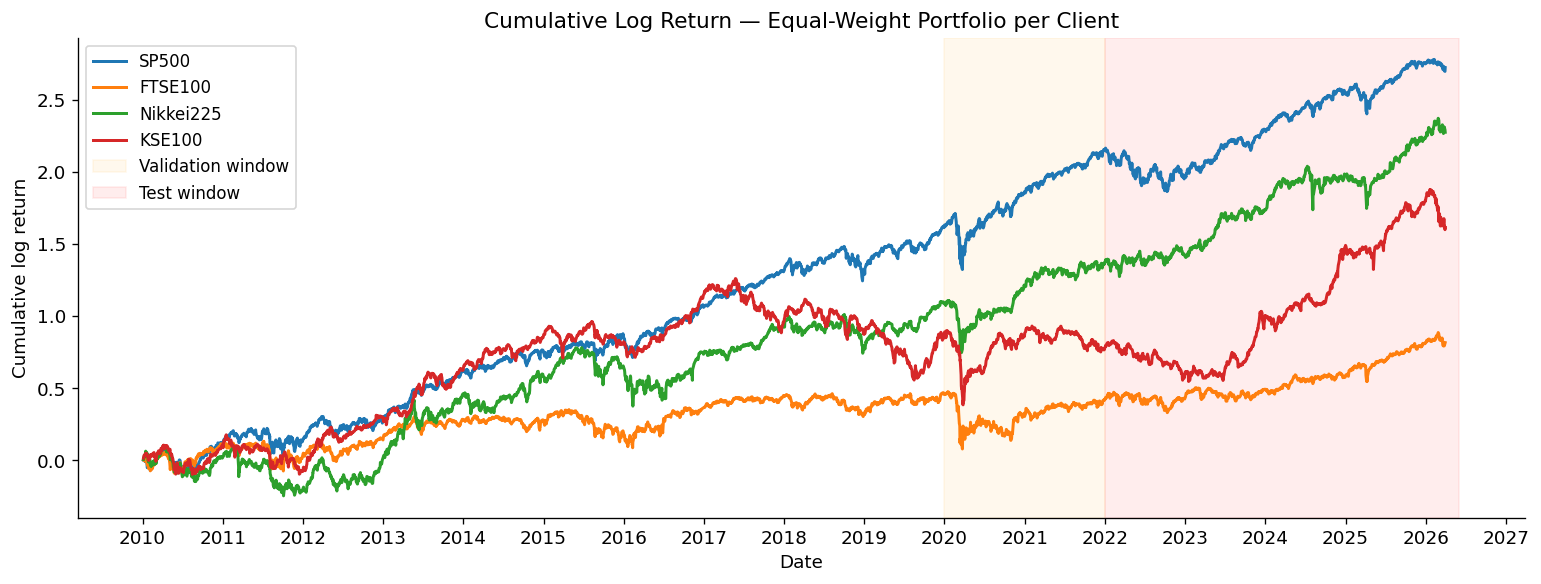

In [24]:
fig, ax = plt.subplots(figsize=(13, 5))
for c, ret in market_ret.items():
    ax.plot(ret.index, ret.cumsum(), label=c, color=PALETTE[c], linewidth=1.8)
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
           alpha=0.07, color='orange', label='Validation window')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2026-06-01'),
           alpha=0.07, color='red', label='Test window')
ax.set_title('Cumulative Log Return — Equal-Weight Portfolio per Client', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative log return')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('figures/cumulative_returns.png', bbox_inches='tight')
plt.show()

### 6.2 — Return Distributions

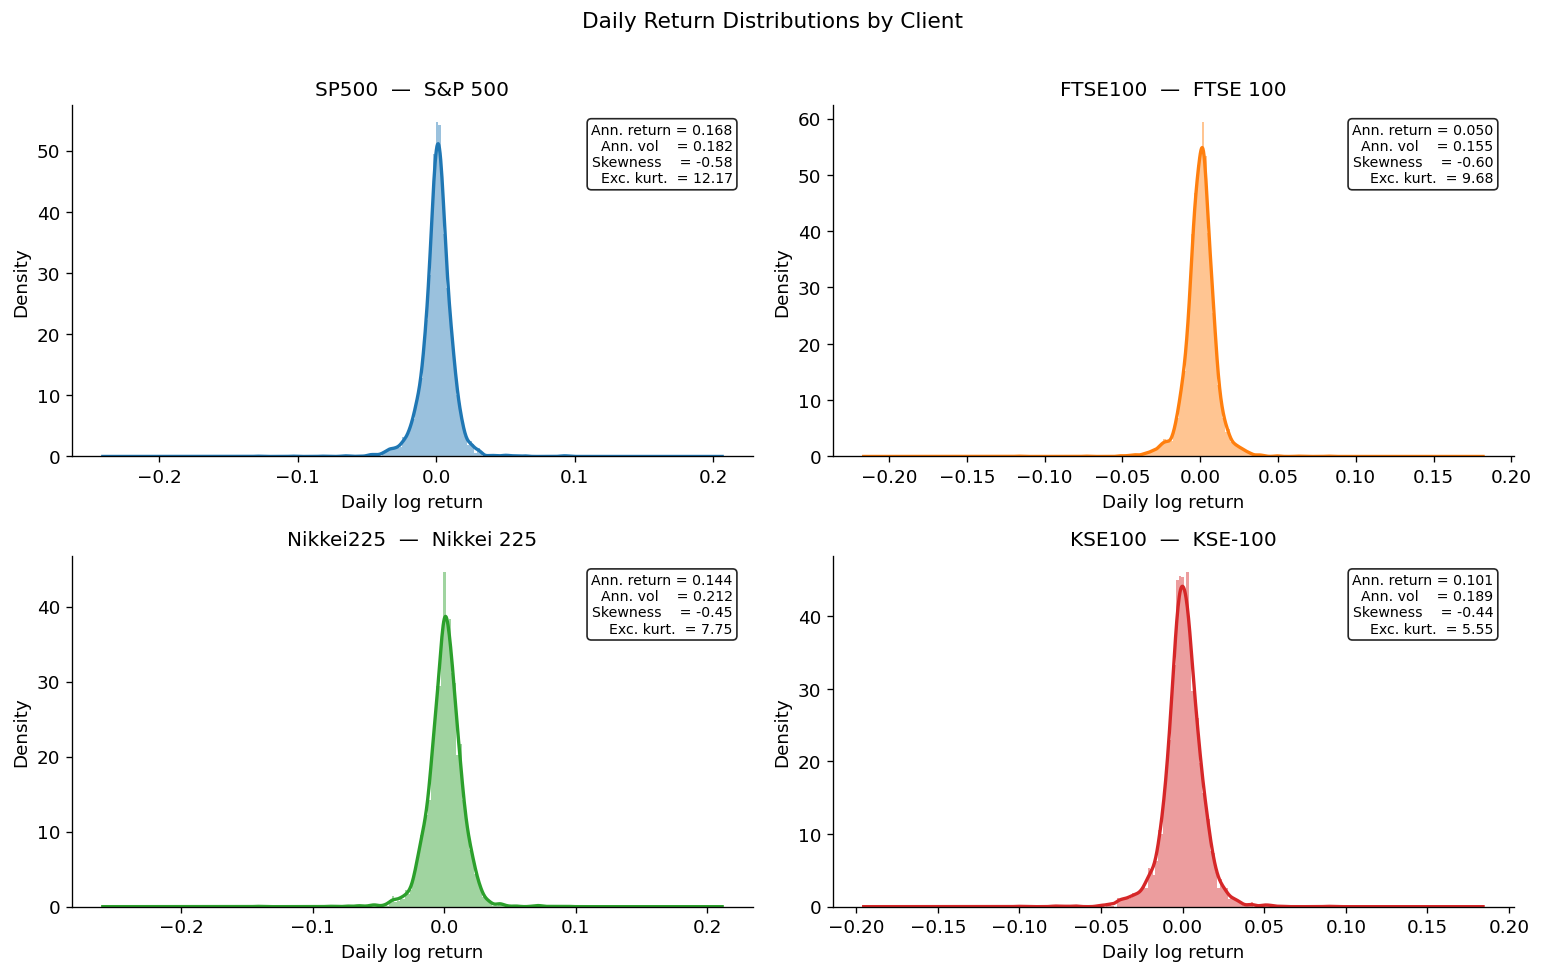


Descriptive statistics (full period 2010–2026):


,Ann. Return,Ann. Vol,Sharpe (rf=0),Skewness,Exc. Kurtosis
Client,,,,,
SP500,0.1679,0.1819,0.923,-0.578,12.172
FTSE100,0.0501,0.1555,0.322,-0.601,9.677
Nikkei225,0.1435,0.2115,0.678,-0.451,7.746
KSE100,0.1010,0.1886,0.536,-0.442,5.552


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
stat_rows = []

for i, (c, ret) in enumerate(market_ret.items()):
    r  = ret.dropna()
    ax = axes[i]
    ax.hist(r, bins=120, density=True, color=PALETTE[c], alpha=0.45, edgecolor='none')
    r.plot.kde(ax=ax, color=PALETTE[c], linewidth=2)
    mu, sigma = r.mean(), r.std()
    sk, ku    = skew(r), kurtosis(r)
    ann_ret   = mu * TRADING_DAYS
    ann_vol   = sigma * np.sqrt(TRADING_DAYS)
    ax.set_title(f'{c}  —  {UNIVERSE[c]["index"]}', fontsize=12)
    ax.set_xlabel('Daily log return')
    ax.set_ylabel('Density')
    ax.text(0.97, 0.95,
            f'Ann. return = {ann_ret:.3f}\nAnn. vol    = {ann_vol:.3f}\n'
            f'Skewness    = {sk:.2f}\nExc. kurt.  = {ku:.2f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    stat_rows.append({'Client': c, 'Ann. Return': round(ann_ret, 4),
                      'Ann. Vol': round(ann_vol, 4),
                      'Sharpe (rf=0)': round(ann_ret / ann_vol, 3),
                      'Skewness': round(sk, 3), 'Exc. Kurtosis': round(ku, 3)})

plt.suptitle('Daily Return Distributions by Client', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/return_distributions.png', bbox_inches='tight')
plt.show()

stats_df = pd.DataFrame(stat_rows).set_index('Client')
print('\nDescriptive statistics (full period 2010–2026):')
stats_df

### 6.3 — Rolling 90-Day Annualised Volatility

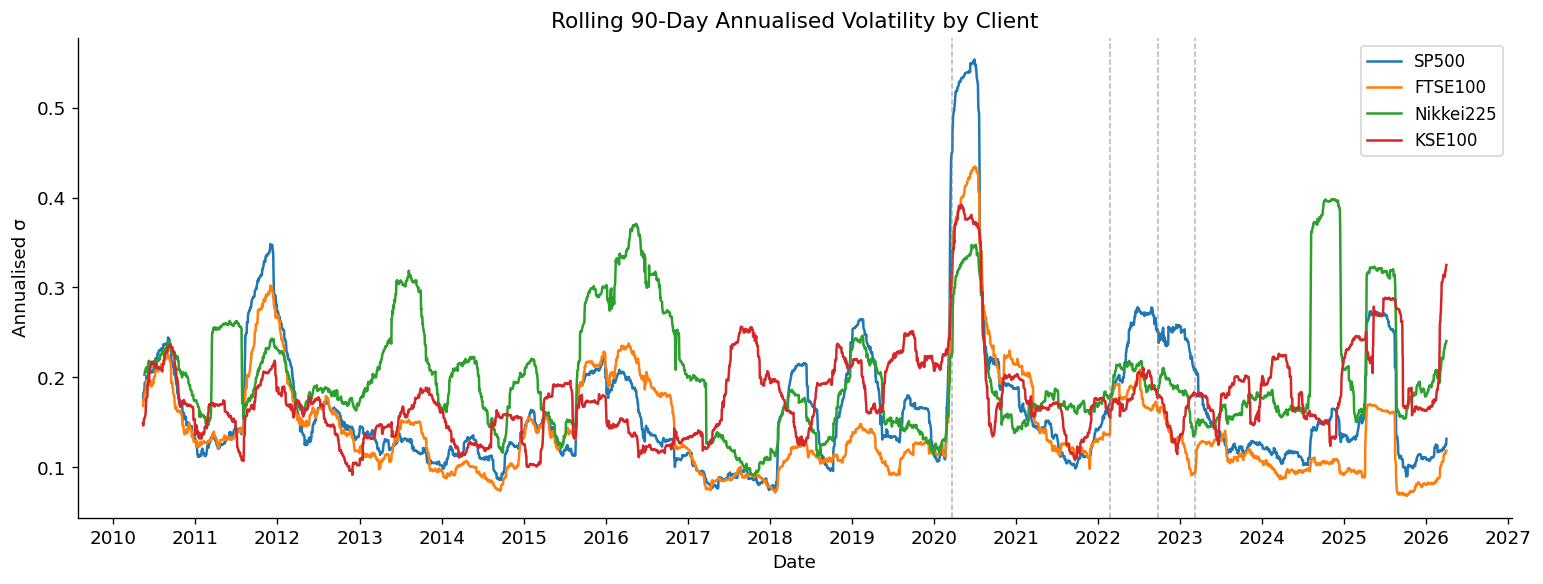

In [26]:
fig, ax = plt.subplots(figsize=(13, 5))
for c, ret in market_ret.items():
    rv = ret.rolling(90).std() * np.sqrt(TRADING_DAYS)
    ax.plot(rv.index, rv, label=c, color=PALETTE[c], linewidth=1.5)
for date_str, label in [('2020-03-20', 'COVID\ncrash'), ('2022-02-24', 'Ukraine\nwar'),
                          ('2022-09-26', 'Inflation\nshock'), ('2023-03-10', 'SVB\ncrisis')]:
    ax.axvline(pd.Timestamp(date_str), color='grey', lw=0.9, ls='--', alpha=0.6)
ax.set_title('Rolling 90-Day Annualised Volatility by Client', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Annualised σ')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('figures/rolling_volatility.png', bbox_inches='tight')
plt.show()

### 6.4 — Cross-Market Correlation Heatmaps

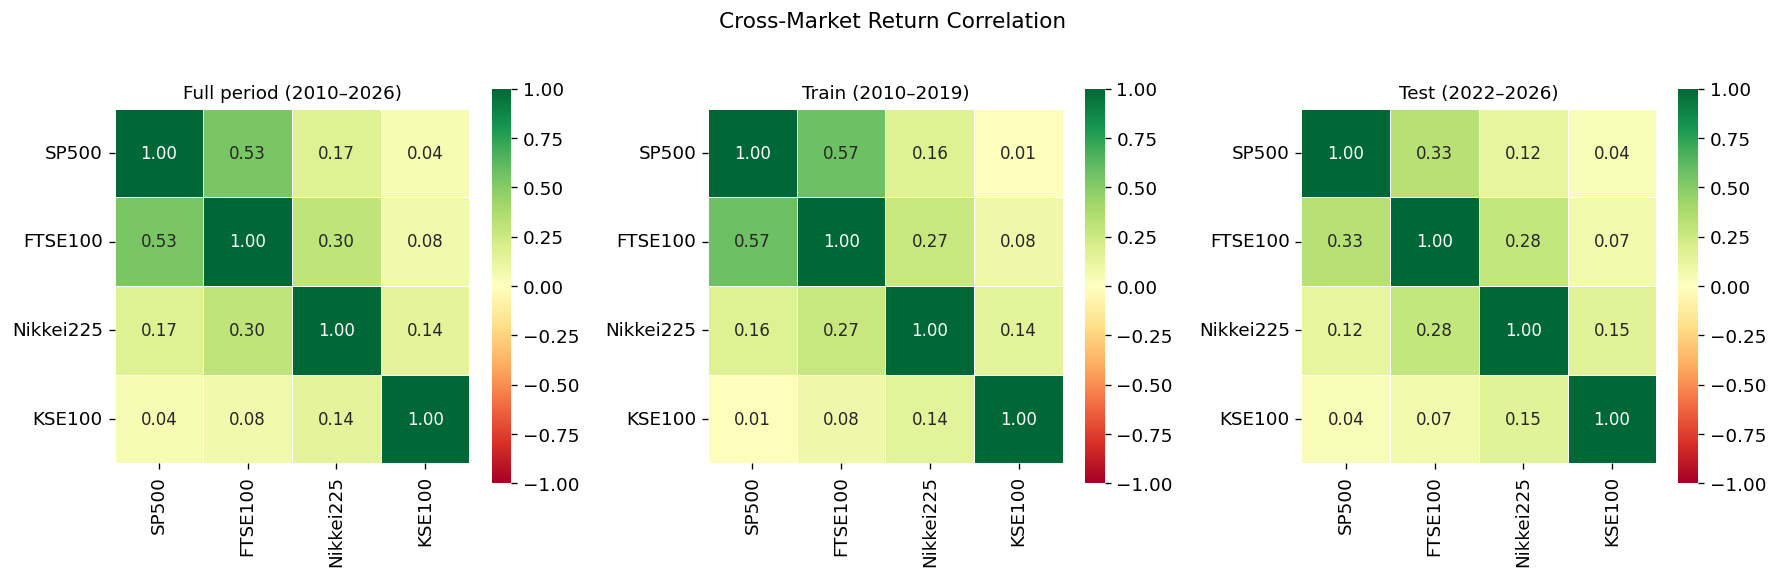

In [27]:
clients_present = list(market_ret_df.columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, label, mask in zip(axes,
    ['Full period (2010–2026)', 'Train (2010–2019)', 'Test (2022–2026)'],
    [slice(None), slice(START_DATE, TRAIN_END), slice('2022-01-01', None)]):
    corr = market_ret_df.loc[mask].dropna().corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=-1, vmax=1, square=True, ax=ax,
                linewidths=0.5, annot_kws={'size': 10})
    ax.set_title(label, fontsize=11)
plt.suptitle('Cross-Market Return Correlation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 6.5 — Per-Asset Return Distributions

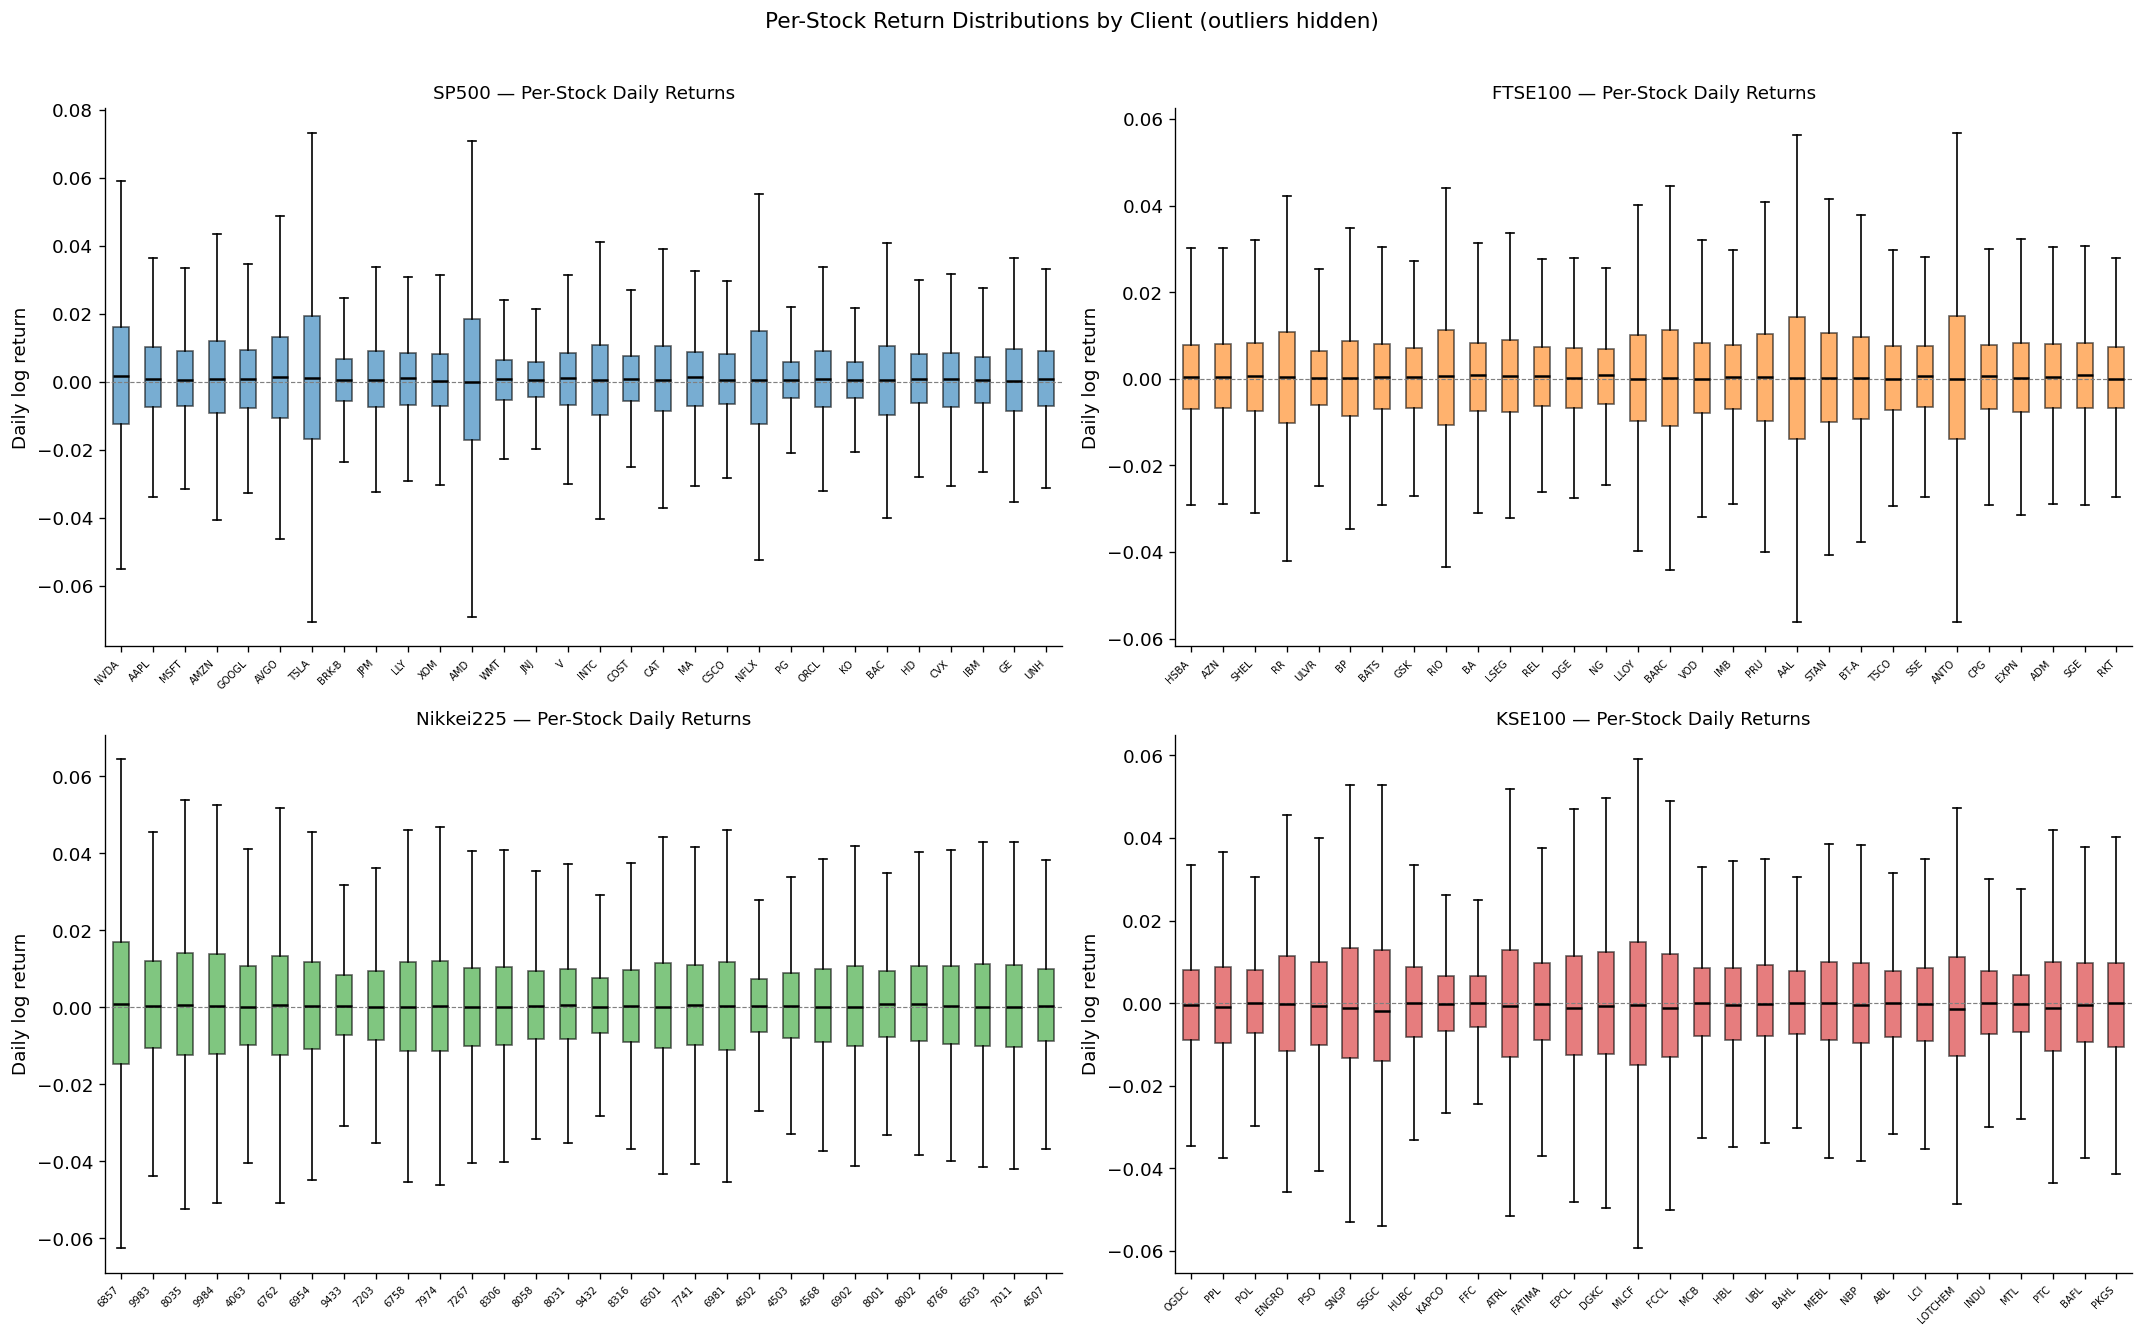

In [28]:
n_clients = len(prices)
ncols = 2
nrows = (n_clients + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5.5 * nrows))
axes = np.array(axes).flatten()

for i, (c, ret) in enumerate(returns.items()):
    ax = axes[i]
    data = [ret[col].dropna().values for col in ret.columns]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch in bp['boxes']:
        patch.set_facecolor(PALETTE[c])
        patch.set_alpha(0.6)
    labels = [t.replace('.L','').replace('.T','').replace('.KA','')
              for t in ret.columns]
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)
    ax.set_title(f'{c} — Per-Stock Daily Returns', fontsize=11)
    ax.set_ylabel('Daily log return')
    ax.axhline(0, color='grey', lw=0.7, ls='--')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Per-Stock Return Distributions by Client (outliers hidden)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/per_stock_boxplot.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Heterogeneity Quantification

A core premise of this project is that the four markets are structurally different. If they were not, there would be no reason to expect asymmetric per-client benefits from federation. We quantify this using Hellinger Distance (HD) between pairwise market return distributions. HD is bounded in [0, 1], symmetric, and is specifically recommended for FL non-IIDness quantification by Jimenez G. et al. (2024) because it directly bounds the aggregation error introduced by FedAvg under heterogeneous distributions.

We also compute an Idiosyncrasy Score per client: 1 − R² from regressing each client's daily return on the equal-weight mean across all four clients. This measures how much of a market's return is unexplained by the federation average — a higher score means the market moves more independently.

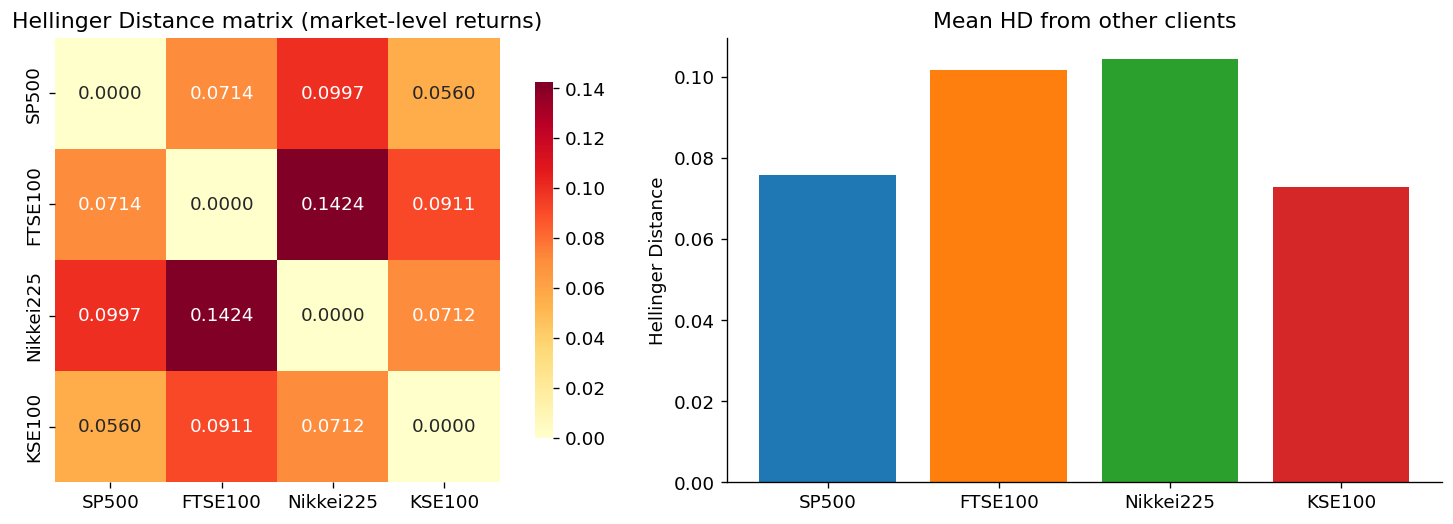


HD matrix:
            SP500  FTSE100  Nikkei225  KSE100
SP500      0.0000   0.0714     0.0997  0.0560
FTSE100    0.0714   0.0000     0.1424  0.0911
Nikkei225  0.0997   0.1424     0.0000  0.0712
KSE100     0.0560   0.0911     0.0712  0.0000

Mean HD per client (use these as HD_SCORES in baselines notebook):
  SP500: 0.0757
  FTSE100: 0.1016
  Nikkei225: 0.1044
  KSE100: 0.0728


In [29]:
def hellinger_distance(a, b, n=200):
    a, b = a.dropna().values, b.dropna().values
    grid = np.linspace(min(a.min(), b.min()), max(a.max(), b.max()), n)
    p = gaussian_kde(a)(grid); p /= p.sum()
    q = gaussian_kde(b)(grid); q /= q.sum()
    return float(np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q))**2)))

clients = list(market_ret.keys())
hd_mat = pd.DataFrame(
    [[hellinger_distance(market_ret[c1], market_ret[c2]) if c1 != c2 else 0.0
      for c2 in clients] for c1 in clients],
    index=clients, columns=clients
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(hd_mat.astype(float), annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[0], square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Hellinger Distance matrix (market-level returns)')

# Per-client HD: average distance from all other clients
hd_scores = {c: hd_mat.loc[c, [x for x in clients if x != c]].mean()
             for c in clients}
axes[1].bar(hd_scores.keys(), hd_scores.values(),
            color=[PALETTE[c] for c in hd_scores])
axes[1].set_title('Mean HD from other clients')
axes[1].set_ylabel('Hellinger Distance')
plt.tight_layout()
plt.savefig('figures/heterogeneity_hd.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nHD matrix:')
print(hd_mat.round(4))
print('\nMean HD per client (use these as HD_SCORES in baselines notebook):')
for c, v in hd_scores.items():
    print(f'  {c}: {v:.4f}')

### 7.1 — Non-IID Characterisation

In [30]:
pd.DataFrame([
    {'Heterogeneity type': 'Feature distribution shift',
     'Present?': 'Yes',
     'Evidence': 'JSD > 0 for all client pairs; return distributions differ in mean, volatility, skew, and kurtosis'},
    {'Heterogeneity type': 'Quantity imbalance',
     'Present?': 'Controlled',
     'Evidence': '30 stocks per client by design — eliminates quantity imbalance as a confound in the FL comparison while increasing cross-sectional signal relative to the original 15-stock setting'},
    {'Heterogeneity type': 'Spatiotemporal skew',
     'Present?': 'Yes',
     'Evidence': 'Different time zones, macro drivers, holiday calendars, and currency regimes across the four markets'},
    {'Heterogeneity type': 'Temporal regime heterogeneity',
     'Present?': 'Yes',
     'Evidence': 'Crisis correlations and bull/bear regime transitions differ between KSE-100 and developed markets'},
]).set_index('Heterogeneity type')

,Present?,Evidence
Heterogeneity type,,
Feature distribution shift,Yes,JSD > 0 for all client pairs; return distribut...
Quantity imbalance,Controlled,30 stocks per client by design — eliminates qu...
Spatiotemporal skew,Yes,"Different time zones, macro drivers, holiday c..."
Temporal regime heterogeneity,Yes,Crisis correlations and bull/bear regime trans...


---
## Section 8 — Feature Engineering

Six features per stock, computed from past prices only. No look-ahead. With 30 stocks per client, each timestep has 180 input features. All features are z-score normalised using training-period statistics and clipped at ±5.

| Feature | Description |
|---|---|
| Log return | Daily log return |
| 5-day rolling mean | Short-term momentum |
| 20-day rolling mean | Medium-term momentum |
| 5-day rolling std | Short-term volatility |
| 20-day rolling std | Medium-term volatility |
| 52-week normalised price | Relative price level |

In [31]:
def build_features(prices_df):
    clean_prices = prices_df.ffill()

    ret = np.log(clean_prices / clean_prices.shift(1))
    ret = ret.clip(lower=-0.5, upper=0.5)

    feats = {
        'log_return':   ret,
        'roll_mean_5':  ret.rolling(5).mean(),
        'roll_std_20':  ret.rolling(20).std(),
        'roll_sharpe_20': ret.rolling(20).mean() / (ret.rolling(20).std() + 1e-8),
        'roll_skew_20': ret.rolling(20).apply(lambda x: pd.Series(x).skew(), raw=False),
        'roll_cumret_60': ret.rolling(60).apply(lambda x: x.sum(), raw=True),
    }

    fm = pd.concat(feats, axis=1).dropna()
    return fm


feature_matrices = {c: build_features(df) for c, df in prices.items()}

for c, fm in feature_matrices.items():
    print(f'[{c}] feature matrix: {fm.shape}  '
          f'| {fm.index.min().date()} → {fm.index.max().date()}')

for c, fm in feature_matrices.items():
    n_stocks = len(UNIVERSE[c]['tickers'])
    n_features = len(fm.columns.get_level_values(0).unique())
    expected_cols = n_stocks * n_features

    assert fm.shape[1] == expected_cols, (
        f'{c}: feature matrix has {fm.shape[1]} columns, expected {expected_cols}.'
    )

    assert fm.index.max() >= pd.Timestamp('2026-03-01'), (
        f'{c}: feature matrix ends too early at {fm.index.max().date()}.'
    )

    print(
        f'[{c}] stocks={n_stocks}, features/stock={n_features}, '
        f'total features/timestep={expected_cols}'
    )

[SP500] feature matrix: (3903, 180)  | 2010-09-23 → 2026-03-31
[FTSE100] feature matrix: (4044, 180)  | 2010-03-29 → 2026-03-31
[Nikkei225] feature matrix: (3932, 180)  | 2010-04-01 → 2026-03-31
[KSE100] feature matrix: (3949, 180)  | 2010-04-27 → 2026-03-31
[SP500] stocks=30, features/stock=6, total features/timestep=180
[FTSE100] stocks=30, features/stock=6, total features/timestep=180
[Nikkei225] stocks=30, features/stock=6, total features/timestep=180
[KSE100] stocks=30, features/stock=6, total features/timestep=180


In [32]:
# Sample snapshot of feature matrix
for c, fm in feature_matrices.items():
    print(f'Feature matrix sample — {c} (first 2 rows):')
    display(fm.head(2).round(5))
    break

Feature matrix sample — SP500 (first 2 rows):


log_return                                                        \
                 NVDA     AAPL     MSFT     AMZN    GOOGL     AVGO     TSLA   
Date                                                                          
2010-09-23    0.01999  0.00406 -0.00734  0.00670 -0.00490  0.02709 -0.01572   
2010-09-24    0.05361  0.01170  0.01422  0.05027  0.02654  0.01165  0.02723   

                                       ... roll_cumret_60                    \
              BRK-B      JPM      LLY  ...           NFLX       PG     ORCL   
Date                                   ...                                    
2010-09-23 -0.01442 -0.02126 -0.00528  ...        0.35444  0.02261  0.22280   
2010-09-24  0.02528  0.01649  0.00667  ...        0.40076  0.03510  0.23031   

                                                                           
                 KO      BAC       HD      CVX      IBM       GE      UNH  
Date                                                                       
2010-09-23  0.14714 -0.10022  0.08282  0.14813  0.05621  0.11590  0.21707  
2010-09-24  0.16420 -0.05427  0.12819  0.17539  0.08752  0.15177  0.23328  

[2 rows x 180 columns]

---
## Section 9 — Data Integrity Checks

In [33]:
print('=' * 65)
print('DATA INTEGRITY')
print('=' * 65)

for c, df in prices.items():
    s = splits[c]
    print(f'\n[{c}]')

    tv = s['train'].index.max() >= s['val'].index.min()
    vt = s['val'].index.max()   >= s['test'].index.min()
    print(f'  No train/val leak : {"FAIL" if tv else "PASS"}')
    print(f'  No val/test leak  : {"FAIL" if vt else "PASS"}')

    raw = np.log(df.ffill() / df.ffill().shift(1))
    extreme = int((raw.abs() > 0.5).sum().sum())
    print(f'  Returns >50%/day  : {extreme}{" (review)" if extreme else ""}')

    for sname, sdf in s.items():
        pct = sdf.isnull().mean().mean() * 100
        print(f'  Missing {sname:<8}: {pct:.2f}%')

    if df.shape[1] != 30:
        print(f'  Stock count       : FAIL ({df.shape[1]} stocks)')
    else:
        print(f'  Stock count       : PASS (30 stocks)')

print()
print('=' * 65)
print('BIAS NOTES')
print('=' * 65)
print("""
Survivorship bias: Universe is a fixed 30-stock blue-chip universe selected
using current/recent index relevance, long public history, liquidity, and
low missingness. Companies delisted before 2026 are excluded. This introduces
survivorship bias, but a fixed universe is required because the portfolio model
has a fixed output dimension.

Universe expansion: The previous deliverables used 15 stocks per client. We
expand to 30 stocks per client to test whether richer cross-sectional signal
makes local/personalized federated learning more viable. This change must be
evaluated by rerunning all baselines and Improvement-1 methods, not only new
methods.

Quantity balance: 30 stocks per client controls for quantity imbalance so that
observed FL performance gaps are attributable to distributional heterogeneity
rather than unequal output dimensions or investable-universe sizes.

Duplicate exposure: Duplicate share classes/economic exposures are avoided
where possible, e.g. GOOGL is kept while GOOG is excluded.

Currency: All prices are in local currency. Log returns are currency-neutral
within each client by construction. For the centralised training baseline, a
per-client mean-return normalisation step is applied before pooling data across
clients.
""")

DATA INTEGRITY

[SP500]
  No train/val leak : PASS
  No val/test leak  : PASS
  Returns >50%/day  : 0
  Missing train   : 0.16%
  Missing val     : 0.00%
  Missing test    : 0.00%
  Stock count       : PASS (30 stocks)

[FTSE100]
  No train/val leak : PASS
  No val/test leak  : PASS
  Returns >50%/day  : 0
  Missing train   : 0.00%
  Missing val     : 0.00%
  Missing test    : 0.02%
  Stock count       : PASS (30 stocks)

[Nikkei225]
  No train/val leak : PASS
  No val/test leak  : PASS
  Returns >50%/day  : 0
  Missing train   : 0.00%
  Missing val     : 0.00%
  Missing test    : 0.00%
  Stock count       : PASS (30 stocks)

[KSE100]
  No train/val leak : PASS
  No val/test leak  : PASS
  Returns >50%/day  : 2 (review)
  Missing train   : 0.26%
  Missing val     : 0.06%
  Missing test    : 0.25%
  Stock count       : PASS (30 stocks)

BIAS NOTES

Survivorship bias: Universe is a fixed 30-stock blue-chip universe selected
using current/recent index relevance, long public history, liqui

---
## Section 10 — Final Summary

In [34]:
rows = []
for c in prices:
    s    = splits[c]
    mret = market_ret[c]
    ann_ret = mret.mean() * TRADING_DAYS
    ann_vol = mret.std()  * np.sqrt(TRADING_DAYS)
    max_dd  = (mret.cumsum() - mret.cumsum().cummax()).min()
    rows.append({
        'Client':       c,
        'Index':        UNIVERSE[c]['index'],
        'Currency':     UNIVERSE[c]['currency'],
        'Stocks':       prices[c].shape[1],
        'Train days':   len(s['train']),
        'Val days':     len(s['val']),
        'Test days':    len(s['test']),
        'Ann. Return':  round(ann_ret, 4),
        'Ann. Vol':     round(ann_vol, 4),
        'Sharpe':       round(ann_ret / ann_vol, 3),
        'Max Drawdown': round(max_dd, 4),
    })

summary = pd.DataFrame(rows).set_index('Client')
print('FINAL DATASET SUMMARY')
print('=' * 80)
summary

FINAL DATASET SUMMARY


,Index,Currency,Stocks,Train days,Val days,Test days,Ann. Return,Ann. Vol,Sharpe,Max Drawdown
Client,,,,,,,,,,
SP500,S&P 500,USD,30,2516,505,1064,0.1679,0.1819,0.923,-0.3889
FTSE100,FTSE 100,GBP,30,2526,507,1071,0.0501,0.1555,0.322,-0.3970
Nikkei225,Nikkei 225,JPY,30,2469,487,1036,0.1435,0.2115,0.678,-0.4050
KSE100,KSE-100,PKR,30,2479,498,1051,0.1010,0.1886,0.536,-0.8745


In [35]:
# Inspect largest daily jumps for KSE stocks
kse = prices["KSE100"]
kse_ret = np.log(kse.ffill() / kse.ffill().shift(1))

extreme_points = []

for ticker in kse_ret.columns:
    r = kse_ret[ticker].dropna()
    top = r.abs().sort_values(ascending=False).head(5)

    for date, abs_val in top.items():
        extreme_points.append({
            "Ticker": ticker,
            "Date": date,
            "Log return": r.loc[date],
            "Abs log return": abs_val,
            "Prev price": kse[ticker].ffill().shift(1).loc[date],
            "Price": kse[ticker].loc[date],
        })

extreme_df = pd.DataFrame(extreme_points)
extreme_df = extreme_df.sort_values("Abs log return", ascending=False)

display(extreme_df.head(30))
extreme_df.to_csv("data/kse_extreme_return_audit.csv", index=False)

,Ticker,Date,Log return,Abs log return,Prev price,Price
20,PSO,2012-11-30,0.555208,0.555208,98.10,170.92
21,PSO,2012-12-03,-0.543251,0.543251,170.92,99.28
130,MTL,2022-04-01,-0.392009,0.392009,545.14,368.35
65,DGKC,2023-05-23,-0.386528,0.386528,68.00,46.20
66,DGKC,2023-05-22,0.380055,0.380055,46.50,68.00
115,LCI,2012-07-13,-0.358853,0.358853,39.40,27.52
0,OGDC,2023-06-22,0.350030,0.350030,73.99,105.00
1,OGDC,2023-06-23,-0.343967,0.343967,105.00,74.44
70,MLCF,2023-06-23,-0.333634,0.333634,38.00,27.22
71,MLCF,2023-06-22,0.331066,0.331066,27.29,38.00


In [36]:
print('Figures saved:')
for f in sorted(os.listdir('figures')):
    print(f'  figures/{f}')

Figures saved:
  figures/correlation_heatmap.png
  figures/cumulative_returns.png
  figures/heterogeneity_hd.png
  figures/per_stock_boxplot.png
  figures/return_distributions.png
  figures/rolling_volatility.png
  figures/split_timeline.png


---
## Summary

Four federated clients, 30 stocks each, strictly chronological splits. The markets differ in return distribution, volatility regime, currency, macro drivers, and correlation structure. The dataset is genuinely heterogeneous across all the non-IID dimensions identified in Jimenez G. et al. (2024), while being balanced in quantity (30 stocks per client) so that FL performance differences in subsequent notebooks are attributable to distributional heterogeneity rather than size imbalance.